In [1]:
# Gerekli kütüphaneleri yükle
!pip install SimpleITK albumentations scikit-image scikit-learn pydicom -q

import os, glob, random
import numpy as np
import SimpleITK as sitk
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import ndimage
from skimage.transform import resize
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Cihaz: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("UYARI: GPU bulunamadı! Runtime > Change runtime type > T4 GPU seçin.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 109.9 MB/s eta 0:00:00
Cihaz: cuda
GPU: Tesla T4


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mehranhabibi134563","key":"c14d4e8730e3b3461a6e95a8be721655"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle datasets download -d kmader/finding-lungs-in-ct-data -p /content/luna16/

Dataset URL: https://www.kaggle.com/datasets/kmader/finding-lungs-in-ct-data
License(s): unknown
100% 1.03G/1.03G [01:05<00:00, 16.8MB/s]



In [ ]:
!unzip /content/luna16/finding-lungs-in-ct-data.zip -d /content/luna16/

Archive:  /content/luna16/finding-lungs-in-ct-data.zip
  inflating: /content/luna16/2d_images.zip  
  inflating: /content/luna16/2d_images/ID_0000_Z_0142.tif  
  inflating: /content/luna16/2d_images/ID_0001_Z_0146.tif  
  inflating: /content/luna16/2d_images/ID_0002_Z_0162.tif  
  inflating: /content/luna16/2d_images/ID_0003_Z_0132.tif  
  inflating: /content/luna16/2d_images/ID_0004_Z_0066.tif  
  inflating: /content/luna16/2d_images/ID_0005_Z_0066.tif  
  inflating: /content/luna16/2d_images/ID_0006_Z_0206.tif  
  inflating: /content/luna16/2d_images/ID_0007_Z_0211.tif  
  inflating: /content/luna16/2d_images/ID_0008_Z_0065.tif  
  inflating: /content/luna16/2d_images/ID_0009_Z_0114.tif  
  inflating: /content/luna16/2d_images/ID_0010_Z_0259.tif  
  inflating: /content/luna16/2d_images/ID_0011_Z_0156.tif  
  inflating: /content/luna16/2d_images/ID_0012_Z_0167.tif  
  inflating: /content/luna16/2d_images/ID_0013_Z_0047.tif  
  inflating: /content/luna16/2d_images/ID_0014_Z_0116.tif  


CT Ön işleme LUNA16 Verisi için

In [6]:
# -------------------------------------------------------
# Bu hücre gerçek .mhd dosyalarınız varsa çalıştırın.
# Sentetik veri kullanıyorsanız atlayabilirsiniz.
# -------------------------------------------------------

def load_ct(filepath):
    """SimpleITK ile .mhd dosyasını okur."""
    itk_img = sitk.ReadImage(filepath)
    img     = sitk.GetArrayFromImage(itk_img)   # [dilim, H, W]
    spacing = np.array(itk_img.GetSpacing())[::-1]  # [z, y, x] mm
    return img, spacing


def normalize_hu(image, min_hu=-1000, max_hu=400):
    """HU değerlerini akciğer penceresine göre [0,1] aralığına çeker."""
    image = np.clip(image, min_hu, max_hu)
    image = (image - min_hu) / float(max_hu - min_hu)
    return image.astype(np.float32)


def extract_lung_mask(image):
    """
    Thresholding + morfolojik işlemlerle akciğer bölgesini izole eder.
    HU < -400: hava/akciğer dokusu
    """
    binary = image < -400
    labeled, n = ndimage.label(binary)
    sizes = ndimage.sum(binary, labeled, range(n + 1))

    mask = np.zeros_like(binary)
    for label_id, size in enumerate(sizes):
        if size > 30000:          # küçük gürültü bölgelerini atla
            mask |= (labeled == label_id)

    mask = ndimage.binary_closing(mask, iterations=3)
    mask = ndimage.binary_fill_holes(mask)
    return mask.astype(np.uint8)


def preprocess_and_save(mhd_paths, out_dir, target_size=256):
    """
    .mhd dosyalarını işleyip .npy olarak kaydeder.
    """
    os.makedirs(f'{out_dir}/images', exist_ok=True)
    os.makedirs(f'{out_dir}/masks',  exist_ok=True)

    for fp in mhd_paths:
        img_raw, spacing = load_ct(fp)
        img_norm = normalize_hu(img_raw)
        lung_msk = extract_lung_mask(img_raw)

        for i in range(img_norm.shape[0]):
            if lung_msk[i].sum() / (target_size**2) < 0.01:
                continue   # akciğer içermeyen dilimleri atla

            slc  = resize(img_norm[i], (target_size, target_size),
                          order=1, preserve_range=True, anti_aliasing=True)
            msk  = resize(lung_msk[i], (target_size, target_size),
                          order=0, preserve_range=True)

            uid = os.path.basename(fp).replace('.mhd', '')
            np.save(f'{out_dir}/images/{uid}_{i:04d}.npy', slc.astype(np.float32))
            np.save(f'{out_dir}/masks/{uid}_{i:04d}.npy',  msk.astype(np.float32))

    print("Ön işleme tamamlandı.")


# Gerçek veri için:
# mhd_files = glob.glob('/content/luna16/subset0/*.mhd')
# preprocess_and_save(mhd_files, '/content/processed')
# DATA_DIR = '/content/processed'

print("Ön işleme fonksiyonları tanımlandı. Gerçek veri için üstteki yorum satırlarını aktifleştirin.")

Ön işleme fonksiyonları tanımlandı. Gerçek veri için üstteki yorum satırlarını aktifleştirin.


Augmentation ve Dataset

In [14]:
# --- DATA_DIR ve veri güvenlik kontrolü ---
if 'DATA_DIR' not in dir():
    DATA_DIR = '/content/synthetic'
    print(f"[UYARI] DATA_DIR tanımlı değildi, varsayılan ayarlandı: {DATA_DIR}")
else:
    print(f"DATA_DIR: {DATA_DIR}")

# Veri yoksa otomatik oluştur
existing = glob.glob(f'{DATA_DIR}/images/*.npy')
if len(existing) == 0:
    print("[BİLGİ] Veri bulunamadı, sentetik CT verileri oluşturuluyor...")
    os.makedirs(f'{DATA_DIR}/images', exist_ok=True)
    os.makedirs(f'{DATA_DIR}/masks',  exist_ok=True)
    N, SIZE = 200, 256
    for i in range(N):
        img = np.random.normal(-0.7, 0.1, (SIZE, SIZE)).astype(np.float32)
        Y, X = np.ogrid[:SIZE, :SIZE]
        lung_area = (X - SIZE//2)**2 + (Y - SIZE//2)**2 < (SIZE//2 - 20)**2
        img[~lung_area] = np.random.normal(0.3, 0.05, (~lung_area).sum())
        mask = np.zeros((SIZE, SIZE), dtype=np.float32)
        cx = random.randint(SIZE//4, 3*SIZE//4)
        cy = random.randint(SIZE//4, 3*SIZE//4)
        r  = random.randint(5, 15)
        nodule = ((X - cx)**2 + (Y - cy)**2 < r**2) & lung_area
        img[nodule]  = np.random.normal(0.6, 0.05, nodule.sum())
        mask[nodule] = 1.0
        np.save(f'{DATA_DIR}/images/img_{i:04d}.npy', img)
        np.save(f'{DATA_DIR}/masks/msk_{i:04d}.npy',  mask)
    print(f"[TAMAM] {N} sentetik örnek oluşturuldu.")
else:
    print(f"[TAMAM] Mevcut veri: {len(existing)} örnek")


def get_train_transforms():
    """Eğitim augmentation pipeline'ı — görüntü ve maskeye eş zamanlı uygulanır."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=15, p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1,
            rotate_limit=10, p=0.4
        ),
        A.ElasticTransform(
            alpha=80, sigma=80 * 0.05,
            alpha_affine=80 * 0.03, p=0.2
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.1, contrast_limit=0.1, p=0.3
        ),
        A.GaussNoise(var_limit=(0.001, 0.005), p=0.2),
    ])


class LungDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])   # (H, W) float32
        mask  = np.load(self.mask_paths[idx])    # (H, W) float32

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        # (H, W) → (1, H, W)
        image = torch.tensor(image).unsqueeze(0)
        mask  = torch.tensor(mask).unsqueeze(0).float()
        return image, mask


# Veri yollarını yükle
all_images = sorted(glob.glob(f'{DATA_DIR}/images/*.npy'))
all_masks  = sorted(glob.glob(f'{DATA_DIR}/masks/*.npy'))
assert len(all_images) == len(all_masks), "Görüntü ve maske sayısı eşleşmiyor!"
print(f"Toplam örnek: {len(all_images)}")

# %70 train / %15 val / %15 test
tr_imgs, tmp_imgs, tr_msks, tmp_msks = train_test_split(
    all_images, all_masks, test_size=0.30, random_state=SEED)
val_imgs, te_imgs, val_msks, te_msks = train_test_split(
    tmp_imgs, tmp_msks, test_size=0.50, random_state=SEED)

print(f"Train: {len(tr_imgs)} | Val: {len(val_imgs)} | Test: {len(te_imgs)}")

train_ds = LungDataset(tr_imgs,  tr_msks,  transform=get_train_transforms())
val_ds   = LungDataset(val_imgs, val_msks, transform=None)
test_ds  = LungDataset(te_imgs,  te_msks,  transform=None)

BATCH = 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=4,     shuffle=False, num_workers=2)

# Batch şeklini kontrol et
imgs, msks = next(iter(train_loader))
print(f"Batch shape — Görüntü: {imgs.shape} | Maske: {msks.shape}")

DATA_DIR: /content/synthetic
[TAMAM] Mevcut veri: 200 örnek
Toplam örnek: 200
Train: 140 | Val: 30 | Test: 30


/tmp/ipykernel_2589/2507362361.py:44: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(
/tmp/ipykernel_2589/2507362361.py:51: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.001, 0.005), p=0.2),


Batch shape — Görüntü: torch.Size([8, 1, 256, 256]) | Maske: torch.Size([8, 1, 256, 256])


U-NET Modeli

In [15]:
class ConvBlock(nn.Module):
    """İki adet Conv2D + BatchNorm + ReLU bloğu."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Klasik U-Net mimarisi.
    Giriş:  (B, 1, 256, 256)
    Çıkış:  (B, 1, 256, 256) — sigmoid sonrası [0,1]

    Encoder (aşağı):  4 seviye, her seviyede kanal sayısı 2x artar
    Bottleneck:       en derin temsil
    Decoder (yukarı): skip connection'larla encoder'dan gelen özellikler eklenir
    """
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        # --- Encoder ---
        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        ch = in_channels
        for f in features:
            self.encoder.append(ConvBlock(ch, f))
            ch = f

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # --- Decoder ---
        self.decoder_ups    = nn.ModuleList()
        self.decoder_convs  = nn.ModuleList()
        rev_features = list(reversed(features))
        ch = features[-1] * 2
        for f in rev_features:
            self.decoder_ups.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)
            )
            self.decoder_convs.append(
                ConvBlock(f * 2, f)   # f*2: upsampled + skip connection
            )
            ch = f

        # --- Çıkış katmanı ---
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder geçişi — skip connection'ları sakla
        skip_connections = []
        for enc in self.encoder:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder geçişi — skip connection'larla birleştir
        skip_connections = skip_connections[::-1]
        for i, (up, conv) in enumerate(zip(self.decoder_ups, self.decoder_convs)):
            x    = up(x)
            skip = skip_connections[i]
            # Boyut uyumsuzluğu olursa kırp
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = conv(x)

        return torch.sigmoid(self.final_conv(x))


# Model oluştur ve özetle
model = UNet(in_channels=1, out_channels=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam parametre:     {total_params:,}")
print(f"Eğitilebilir param:   {trainable:,}")

# Boyut kontrolü
dummy = torch.randn(1, 1, 256, 256).to(DEVICE)
out   = model(dummy)
print(f"Giriş shape:  {dummy.shape}")
print(f"Çıkış shape:  {out.shape}")

Toplam parametre:     31,036,481
Eğitilebilir param:   31,036,481
Giriş shape:  torch.Size([1, 1, 256, 256])
Çıkış shape:  torch.Size([1, 1, 256, 256])


Loss fonksiyonu ve eğitim

In [19]:
# -------------------------------------------------------
# Loss Fonksiyonları
# -------------------------------------------------------

def dice_loss(pred, target, smooth=1e-6):
    """
    Dice Loss — medikal segmentasyon için standart.
    Küçük ve dengesiz sınıflar (nodüller) için Binary Cross-Entropy'den daha iyi.
    """
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred, target, dice_w=0.5, bce_w=0.5):
    """
    Dice Loss + Binary Cross-Entropy kombinasyonu.
    BCE: piksel başına hata, Dice: bölge örtüşmesi.
    """
    bce  = nn.BCELoss()(pred, target)
    dice = dice_loss(pred, target)
    return bce_w * bce + dice_w * dice


# -------------------------------------------------------
# Metrikler
# -------------------------------------------------------

def compute_metrics(pred, target, threshold=0.5, smooth=1e-6):
    """
    Dice Coefficient, IoU, Precision, Recall hesaplar.
    pred:   sigmoid çıkışı [0,1]
    target: binary maske {0,1}
    """
    pred_bin = (pred > threshold).float()

    TP = (pred_bin * target).sum().item()
    FP = (pred_bin * (1 - target)).sum().item()
    FN = ((1 - pred_bin) * target).sum().item()

    dice      = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)
    iou       = (TP + smooth)     / (TP + FP + FN + smooth)
    precision = (TP + smooth)     / (TP + FP + smooth)
    recall    = (TP + smooth)     / (TP + FN + smooth)

    return {'dice': dice, 'iou': iou, 'precision': precision, 'recall': recall}


# -------------------------------------------------------
# Eğitim ve Validasyon Döngüleri
# -------------------------------------------------------

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    metrics_sum = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}

    for images, masks in loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        m = compute_metrics(preds.detach(), masks)
        for k in metrics_sum:
            metrics_sum[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    metrics_sum = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0}

    for images, masks in loader:
        images = images.to(device)
        masks  = masks.to(device)

        preds = model(images)
        loss  = combined_loss(preds, masks)

        total_loss += loss.item()
        m = compute_metrics(preds, masks)
        for k in metrics_sum:
            metrics_sum[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}


# -------------------------------------------------------
# Ana Eğitim Döngüsü
# -------------------------------------------------------

EPOCHS    = 30
LR        = 1e-4
SAVE_PATH = '/content/best_model.pth'

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': [],
           'train_dice': [], 'val_dice': []}

best_val_loss = float('inf')
early_stop_patience = 10
no_improve = 0

print(f"Eğitim başlıyor — {EPOCHS} epoch, LR={LR}")
print("-" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Dice':>10} | {'Val Dice':>8}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_m = evaluate(model, val_loader, DEVICE)

    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_dice'].append(tr_m['dice'])
    history['val_dice'].append(va_m['dice'])

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {va_loss:>8.4f} | "
          f"{tr_m['dice']:>10.4f} | {va_m['dice']:>8.4f}")

    # En iyi modeli kaydet
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"          ✓ Model kaydedildi (val_loss={va_loss:.4f})")
    else:
        no_improve += 1
        if no_improve >= early_stop_patience:
            print(f"\nEarly stopping: {early_stop_patience} epoch boyunca iyileşme yok.")
            break

print("-" * 65)
print(f"Eğitim tamamlandı. En iyi val_loss: {best_val_loss:.4f}")

Eğitim başlıyor — 30 epoch, LR=0.0001
-----------------------------------------------------------------
 Epoch | Train Loss | Val Loss | Train Dice | Val Dice
-----------------------------------------------------------------
     1 |     0.5946 |   0.5863 |     0.9220 |   0.9282
          ✓ Model kaydedildi (val_loss=0.5863)
     2 |     0.5894 |   0.5841 |     0.9293 |   0.9701
          ✓ Model kaydedildi (val_loss=0.5841)
     3 |     0.5855 |   0.5812 |     0.9333 |   0.9788
          ✓ Model kaydedildi (val_loss=0.5812)
     4 |     0.5814 |   0.5761 |     0.9410 |   0.9329
          ✓ Model kaydedildi (val_loss=0.5761)
     5 |     0.5778 |   0.5706 |     0.9289 |   0.9545
          ✓ Model kaydedildi (val_loss=0.5706)
     6 |     0.5744 |   0.5671 |     0.9368 |   0.9618
          ✓ Model kaydedildi (val_loss=0.5671)
     7 |     0.5701 |   0.5641 |     0.9376 |   0.9219
          ✓ Model kaydedildi (val_loss=0.5641)
     8 |     0.5661 |   0.5586 |     0.9378 |   0.9684
      

Eğitim grafikleri

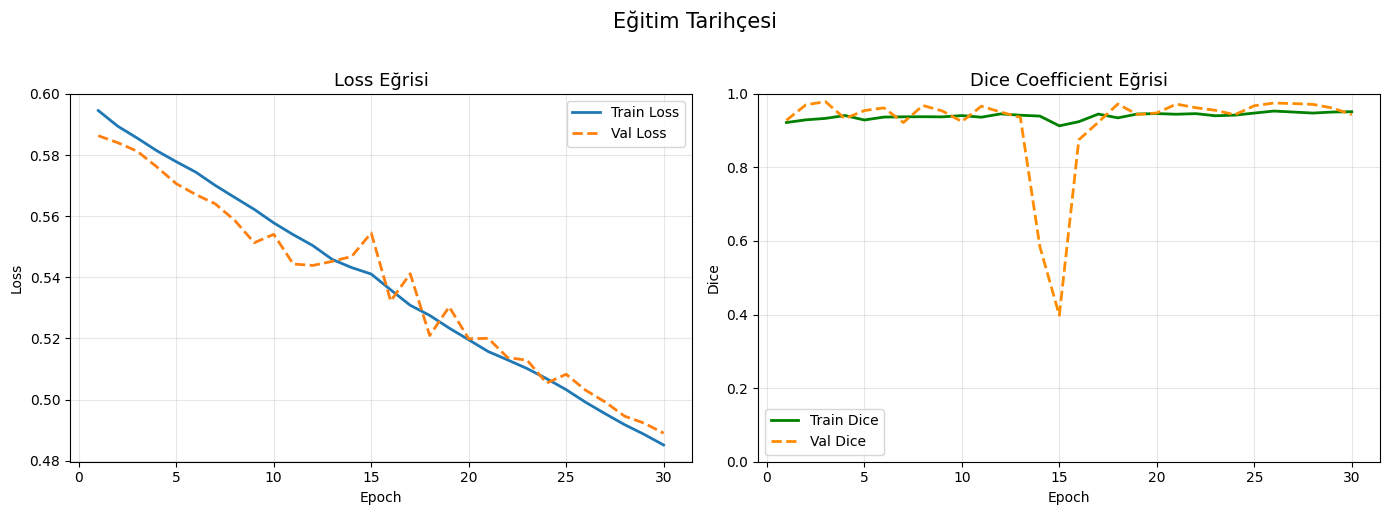

Grafik /content/training_history.png olarak kaydedildi.


In [20]:
epochs_ran = len(history['train_loss'])
ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
axes[0].plot(ep, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_title('Loss Eğrisi', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice grafiği
axes[1].plot(ep, history['train_dice'], label='Train Dice', linewidth=2, color='green')
axes[1].plot(ep, history['val_dice'],   label='Val Dice',   linewidth=2, linestyle='--', color='darkorange')
axes[1].set_title('Dice Coefficient Eğrisi', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Eğitim Tarihçesi', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik /content/training_history.png olarak kaydedildi.")

Test seti değerlndirme

TEST SETİ SONUÇLARI
DICE        : 0.9391 ± 0.0094
IOU         : 0.8854 ± 0.0168
PRECISION   : 0.8854 ± 0.0168
RECALL      : 1.0000 ± 0.0000


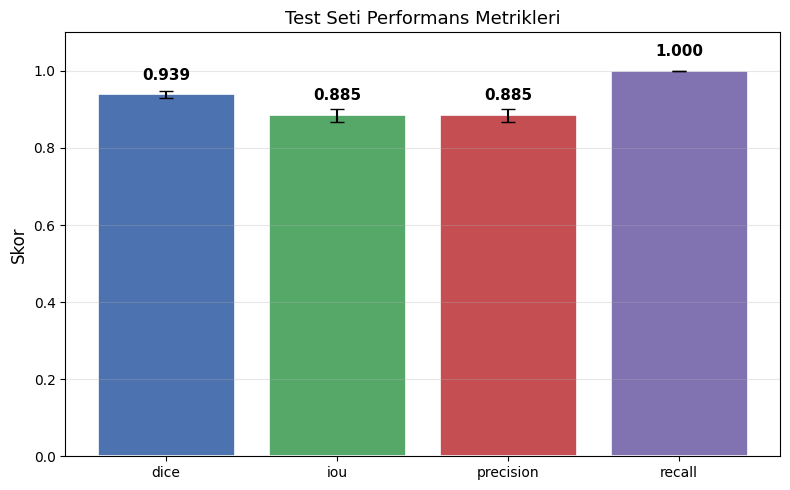

In [21]:
# En iyi modeli yükle
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Test seti üzerinde tüm metrikleri hesapla
test_metrics = {'dice': [], 'iou': [], 'precision': [], 'recall': []}

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        preds  = model(images)
        m = compute_metrics(preds, masks)
        for k in test_metrics:
            test_metrics[k].append(m[k])

# Ortalama ve standart sapma
print("=" * 45)
print("TEST SETİ SONUÇLARI")
print("=" * 45)
for metric, values in test_metrics.items():
    arr  = np.array(values)
    print(f"{metric.upper():<12}: {arr.mean():.4f} ± {arr.std():.4f}")
print("=" * 45)

# Bar grafik
metric_names = list(test_metrics.keys())
means  = [np.mean(test_metrics[k]) for k in metric_names]
stds   = [np.std(test_metrics[k])  for k in metric_names]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metric_names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Test Seti Performans Metrikleri', fontsize=13)
ax.grid(axis='y', alpha=0.3)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

Görselleştirme: CT / Gerçek Maske / Tahmin Karşılaştırması

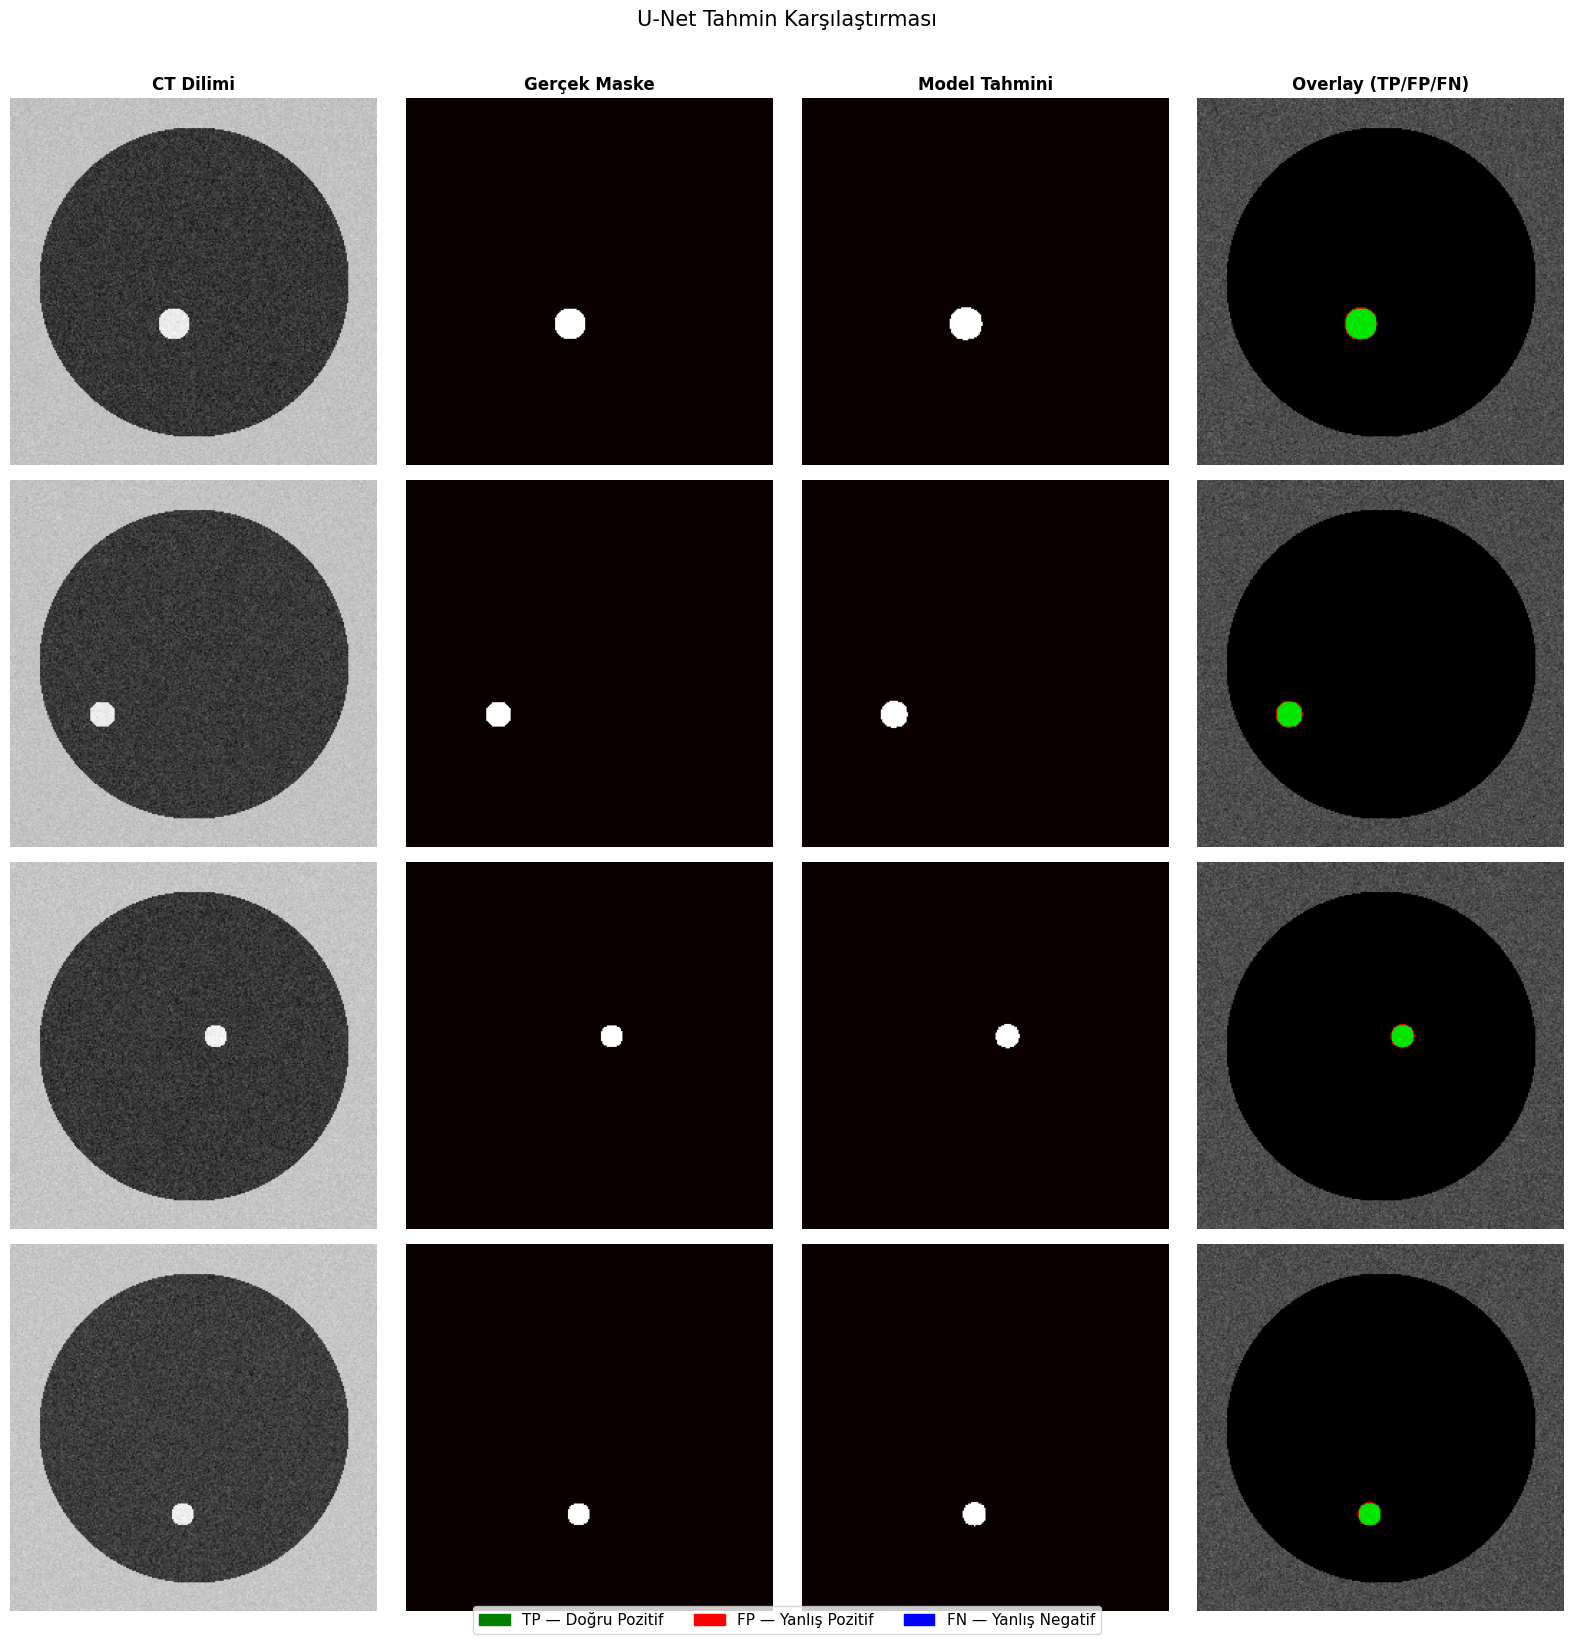

Görsel /content/predictions.png olarak kaydedildi.


In [22]:
def visualize_predictions(model, dataset, device, n=4, threshold=0.5):
    """
    n adet örnek için CT dilimi, gerçek maske ve model tahminini
    yan yana görselleştirir.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    col_titles = ['CT Dilimi', 'Gerçek Maske', 'Model Tahmini', 'Overlay (TP/FP/FN)']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight='bold')

    with torch.no_grad():
        for row, idx in enumerate(indices):
            image, mask = dataset[idx]
            pred = model(image.unsqueeze(0).to(device))
            pred_bin = (pred.squeeze().cpu().numpy() > threshold).astype(np.float32)

            img_np  = image.squeeze().numpy()
            mask_np = mask.squeeze().numpy()

            # Metrikleri hesapla
            m = compute_metrics(
                torch.tensor(pred_bin).unsqueeze(0),
                torch.tensor(mask_np).unsqueeze(0)
            )

            # 1. CT
            axes[row, 0].imshow(img_np, cmap='gray')
            axes[row, 0].axis('off')

            # 2. Gerçek maske
            axes[row, 1].imshow(mask_np, cmap='hot', vmin=0, vmax=1)
            axes[row, 1].axis('off')

            # 3. Tahmin
            axes[row, 2].imshow(pred_bin, cmap='hot', vmin=0, vmax=1)
            axes[row, 2].set_xlabel(
                f"Dice={m['dice']:.3f}  IoU={m['iou']:.3f}", fontsize=9)
            axes[row, 2].axis('off')

            # 4. Renk kodlu overlay: TP=yeşil, FP=kırmızı, FN=mavi
            overlay = np.stack([img_np]*3, axis=-1)
            TP = (pred_bin == 1) & (mask_np == 1)
            FP = (pred_bin == 1) & (mask_np == 0)
            FN = (pred_bin == 0) & (mask_np == 1)

            overlay[TP, 0] = 0;   overlay[TP, 1] = 0.9; overlay[TP, 2] = 0   # yeşil
            overlay[FP, 0] = 0.9; overlay[FP, 1] = 0;   overlay[FP, 2] = 0   # kırmızı
            overlay[FN, 0] = 0;   overlay[FN, 1] = 0;   overlay[FN, 2] = 0.9 # mavi

            axes[row, 3].imshow(np.clip(overlay, 0, 1))
            axes[row, 3].axis('off')

    # Renk açıklaması
    legend = [
        mpatches.Patch(color='green', label='TP — Doğru Pozitif'),
        mpatches.Patch(color='red',   label='FP — Yanlış Pozitif'),
        mpatches.Patch(color='blue',  label='FN — Yanlış Negatif'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3,
               fontsize=11, bbox_to_anchor=(0.5, -0.01))

    plt.suptitle('U-Net Tahmin Karşılaştırması', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Görsel /content/predictions.png olarak kaydedildi.")


visualize_predictions(model, test_ds, DEVICE, n=4)

Modeli kaytedelim

In [23]:
# Modeli Google Drive'a kaydet (isteğe bağlı)
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(model.state_dict(), '/content/drive/MyDrive/lung_unet_best.pth')

# Yerel olarak indir
from google.colab import files
files.download(SAVE_PATH)
files.download('/content/training_history.png')
files.download('/content/test_metrics.png')
files.download('/content/predictions.png')

print("Tüm dosyalar indirildi.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tüm dosyalar indirildi.


In [25]:
from google.colab import files

# Örneğin, 'output.txt' adında bir dosya oluşturduysan:
with open("output.txt", "w") as f:
    f.write("Merhaba, bu dosya Colab'da oluşturuldu!")

# Dosyayı indir
files.download("output.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>